In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib

In [ ]:
df = pd.read_pickle("cleaned_dataset.pkl")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df.iloc[:,0:20].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1399 entries, 0 to 1871
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   experience_years    1399 non-null   int64
 1   python              1399 non-null   int64
 2   java                1399 non-null   int64
 3   c_cpp               1399 non-null   int64
 4   javascript          1399 non-null   int64
 5   typescript          1399 non-null   int64
 6   html_css            1399 non-null   int64
 7   react               1399 non-null   int64
 8   angular_vue         1399 non-null   int64
 9   nodejs              1399 non-null   int64
 10  fastapi_flask       1399 non-null   int64
 11  django              1399 non-null   int64
 12  sql                 1399 non-null   int64
 13  nosql               1399 non-null   int64
 14  mongodb             1399 non-null   int64
 15  postgresql          1399 non-null   int64
 16  pandas_numpy        1399 non-null   int64
 17  

In [ ]:
df.iloc[:,20:40].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1399 entries, 0 to 1871
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   nlp                            1399 non-null   int64  
 1   computer_vision                1399 non-null   int64  
 2   docker                         1399 non-null   int64  
 3   kubernetes                     1399 non-null   int64  
 4   git                            1399 non-null   int64  
 5   linux                          1399 non-null   int64  
 6   aws                            1399 non-null   int64  
 7   azure_gcp                      1399 non-null   int64  
 8   ci_cd                          1399 non-null   int64  
 9   terraform                      1399 non-null   int64  
 10  cybersecurity_basics           1399 non-null   int64  
 11  penetration_testing            1399 non-null   int64  
 12  flutter_react_native           1399 non-null   int64 

In [ ]:
df.iloc[:,40:].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1399 entries, 0 to 1871
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   education_level_M.Tech / MCA  1399 non-null   float64
 1   education_level_Self-Taught   1399 non-null   float64
 2   programming_score             1399 non-null   int64  
 3   data_skill_score              1399 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 54.6 KB


In [ ]:
y = df.iloc[:,33]

In [ ]:
x = df.iloc[:,1:33]

In [ ]:
x.columns

Index(['python', 'java', 'c_cpp', 'javascript', 'typescript', 'html_css',
       'react', 'angular_vue', 'nodejs', 'fastapi_flask', 'django', 'sql',
       'nosql', 'mongodb', 'postgresql', 'pandas_numpy', 'scikit_learn',
       'deep_learning', 'pytorch_tensorflow', 'nlp', 'computer_vision',
       'docker', 'kubernetes', 'git', 'linux', 'aws', 'azure_gcp', 'ci_cd',
       'terraform', 'cybersecurity_basics', 'penetration_testing',
       'flutter_react_native'],
      dtype='object')

In [ ]:
print(type(x),type(y))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=69)

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
pca = PCA(n_components=0.95,random_state=69)

In [ ]:
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [ ]:
print(x_train_pca.shape)

(1119, 29)


In [ ]:
print(pca.explained_variance_ratio_)

[0.13512952 0.1167319  0.07802769 0.05472567 0.04847207 0.04346834
 0.03447815 0.03079943 0.03019561 0.02898506 0.02676213 0.02444536
 0.02331448 0.02299746 0.02243874 0.02228102 0.02173503 0.02049502
 0.0194002  0.01843066 0.01823753 0.0176142  0.01632557 0.01572124
 0.0153766  0.01468826 0.01430205 0.0142663  0.01356544]


In [ ]:
print(pca.explained_variance_ratio_.sum())


0.9634107524332345


In [ ]:
cumulative_variance = pca.explained_variance_ratio_.cumsum()

In [ ]:
cumulative_variance

array([0.13512952, 0.25186143, 0.32988912, 0.38461479, 0.43308686,
       0.4765552 , 0.51103336, 0.54183279, 0.5720284 , 0.60101346,
       0.62777559, 0.65222096, 0.67553544, 0.69853289, 0.72097164,
       0.74325265, 0.76498769, 0.78548271, 0.80488291, 0.82331357,
       0.8415511 , 0.85916529, 0.87549087, 0.89121211, 0.9065887 ,
       0.92127697, 0.93557902, 0.94984532, 0.96341075])

In [ ]:
n_components_95 = (cumulative_variance>=0.95).argmax()+1

C:\Users\anshu\AppData\Local\Temp\ipykernel_9152\2809639168.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


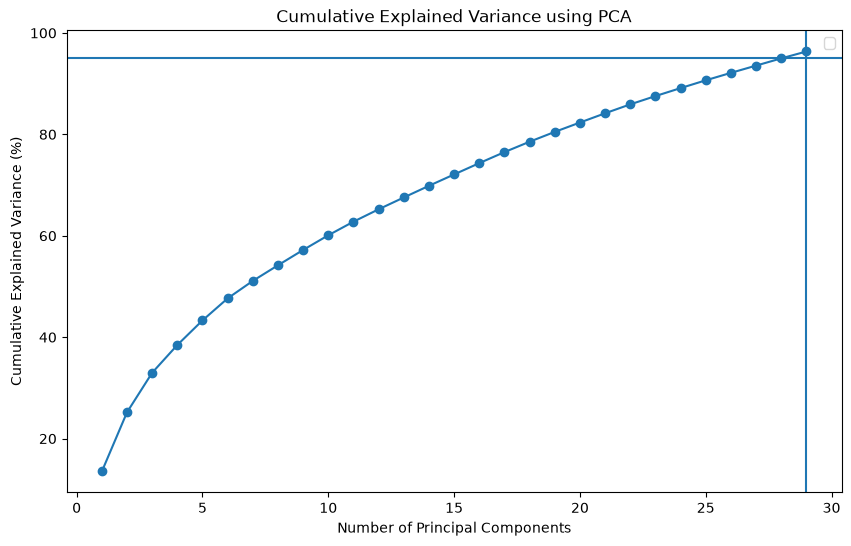

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(cumulative_variance) + 1),cumulative_variance * 100,marker="o")
plt.axhline(y=95)
plt.axvline(x=n_components_95)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance using PCA")
plt.legend()
plt.show()

In [ ]:

joblib.dump(scaler,"standard_scaler.pkl")

['standard_scaler.pkl']